# SmartStay AI: Keşifsel Veri Analizi (EDA) ve Veri Ön İşleme Hattı

Bu doküman, **SmartStay AI** projesinin veri bilimi modülü kapsamındaki Keşifsel Veri Analizi (EDA) ve Veri Ön İşleme (Data Preprocessing) süreçlerini içermektedir. Inside Airbnb İstanbul veri seti üzerinde yapısal, istatistiksel ve dağılım analizleri gerçekleştirilmiş; ardından veri seti temizlenerek modelleme adımlarına uygun hale getirilmiştir.

---

### Metodolojik Süreç
1. **Keşifsel Veri Analizi (Bölüm I):**
   * Veri seti şemasının, bellek kullanımının ve veri tiplerinin incelenmesi (`df.info()`, `df.describe()`).
   * Eksik veri dağılımının ve seyreklik (sparsity) oranlarının analizi.
   * Değişkenlerin sayısal ve kategorik olarak ayrıştırılması.
   * Hedef değişken (`price`) dağılımının, çarpıklığının ve aşırı değerlerinin analiz edilmesi.
   * Oda tipleri (`room_type`) ve konumsal dağılımların (`neighbourhood_cleansed`) incelenmesi.
2. **Veri Temizleme ve İmpütasyon (Bölüm II):**
   * %50'den fazla eksik veri içeren 14 sütunun ayıklanması.
   * Fiyat kolonunun sayısal tipe dönüştürülmesi ve etiketi eksik gözlemlerin filtrelenmesi.
   * Kalan sayısal ve kategorik değişkenlerin uygun istatistiksel yöntemlerle (medyan, sıfır veya kategori ataması) doldurulması.
   * Temizlenmiş veri setinin `data/processed/cleaned_listings.csv` konumuna serileştirilmesi.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. Ham Veri Setinin Belleğe Yüklenmesi

In [2]:
raw_data_path = os.path.join('..', 'data', 'raw', 'listings.csv')
df_raw = pd.read_csv(raw_data_path)

print(f"Gözlem (Satır) Sayısı: {df_raw.shape[0]:,}")
print(f"Değişken (Sütun) Sayısı: {df_raw.shape[1]}")
df_raw.head(3)

Gözlem (Satır) Sayısı: 26,631
Değişken (Sütun) Sayısı: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,25436,https://www.airbnb.com/rooms/25436,20260630053558,2026-07-03,previous scrape,In the forest Sea view Two minutes to the city.,Our house is in Bebek Koru. If you want villag...,NaN,https://a0.muscache.com/pictures/b64c3ef0-2256...,105823,https://www.airbnb.com/users/show/105823,1462509707466640732,https://www.airbnb.com/users/profile/146250970...,Yesim,NaN,16,2,15,6,"İstanbul, Turkey","Merhabalar . Kuş sesi , akan su sesi ile uyan...",NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/067a8...,NaN,1,NaN,NaN,t,t,NaN,Besiktas,NaN,41.08,29.04,Entire rental unit,Entire home/apt,3,NaN,1 bath,2.00,NaN,"[""Sound system"", ""Barbecue utensils"", ""Free pa...",NaN,NaN,NaN,NaN,NaN,NaN,100.00,160.00,100.00,100.00,160.00,160.00,100.00,160.00,NaN,t,0,0,0,0,2026-07-03,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
1,34177,https://www.airbnb.com/rooms/34177,20260630053558,2026-07-03,previous scrape,PETIT HOUSE,My petit house is located in the bosphorous an...,NaN,https://a0.muscache.com/pictures/47356451/c288...,147330,https://www.airbnb.com/users/show/147330,1462510899379737925,https://www.airbnb.com/users/profile/146251089...,Ercan,NaN,16,0,15,6,"Istanbul, Turkey",grounded and well-traveled interior architect,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/147330/profil...,NaN,2,NaN,NaN,t,t,NaN,Besiktas,NaN,41.07,29.04,Entire home,Entire home/apt,3,NaN,1 bath,1.00,NaN,"[""Microwave"", ""Fire extinguisher"", ""Refrigerat...","$1,356.82",2026-07-04,2026-10-12,135681.69,1356.82,"{""quote"": {""taxes"": null, ""currency"": null, ""d...",100.00,365.00,100.00,100.00,365.00,365.00,100.00,365.00,NaN,t,29,59,89,364,2026-07-03,16,0,0,181,0,0,0.00,2015-12-29,2024-01-03,4.69,4.69,4.88,4.88,4.81,4.69,4.81,NaN,NaN,2,2,0,0,0.13
2,42835,https://www.airbnb.com/rooms/42835,20260630053558,2026-07-03,previous scrape,Cozy apartment in the heart of Istanbul,Welcome to our cozy 2-bedroom apartment locate...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,187026,https://www.airbnb.com/users/show/187026,1462512109122697564,https://www.airbnb.com/users/profile/146251210...,Attila,NaN,15,11,15,6,"Istanbul, Turkey",I am from Istanbul/ Turkey. I will do my best ...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/187026/profil...,NaN,3,NaN,NaN,t,t,NaN,Sisli,NaN,41.04,28.98,Entire rent

## 3. Veri Şeması ve Tip Analizi

In [3]:
df_raw.info(verbose=False, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 26631 entries, 0 to 26630
Columns: 90 entries, id to reviews_per_month
dtypes: float64(37), int64(24), str(29)
memory usage: 18.3 MB


In [4]:
dtype_distribution = df_raw.dtypes.value_counts().reset_index()
dtype_distribution.columns = ['Veri Tipi', 'Kolon Sayısı']
dtype_distribution

,Veri Tipi,Kolon Sayısı
0,float64,37
1,str,29
2,int64,24


In [5]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,26631.00,954563225373855616.00,536161971076064384.00,25436.00,707238894309436800.00,1000515312687092864.00,1406669945719909120.00,1718639795647937792.00
scrape_id,26631.00,20260630053558.00,0.00,20260630053558.00,20260630053558.00,20260630053558.00,20260630053558.00,20260630053558.00
neighborhood_overview,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,26631.00,22828919735197600.00,195028741099205472.00,85923.00,184465942.50,421844037.00,520046156.00,1717166899612739840.00
host_profile_id,26631.00,1476805616109044224.00,39046339178448928.00,1462509243176855552.00,1463541145760058112.00,1469443363461647360.00,1470305763658696192.00,1717940683362909184.00
host_since,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,26631.00,5.23,3.63,0.00,3.00,4.00,8.00,16.00
hosts_time_as_user_months,26631.00,5.88,3.57,0.00,3.00,6.00,9.00,11.00
hosts_time_as_host_years,26631.00,4.17,3.25,0.00,2.00,3.00,6.00,15.00
hosts_time_as_host_months,26631.00,5.67,3.47,0.00,3.00,6.00,9.00,11.00


## 4. Değişkenlerin Sayısal ve Kategorik Olarak Sınıflandırılması

In [6]:
numerical_columns = df_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df_raw.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()

print(f"Sayısal Değişken Sayısı: {len(numerical_columns)}")
print(f"Kategorik / Metin Değişken Sayısı: {len(categorical_columns)}")

Sayısal Değişken Sayısı: 61
Kategorik / Metin Değişken Sayısı: 29


## 5. Eksik Değer (Missing Value) ve Seyreklik Analizi

In [7]:
missing_counts = df_raw.isnull().sum()
missing_ratios = (100 * missing_counts / len(df_raw))

missing_summary = pd.DataFrame({
    'Degisken_Adi': df_raw.columns,
    'Veri_Tipi': df_raw.dtypes.astype(str),
    'Eksik_Sayisi': missing_counts,
    'Eksik_Orani_Pct': missing_ratios
}).reset_index(drop=True)

missing_summary_filtered = missing_summary[missing_summary['Eksik_Sayisi'] > 0].sort_values(
    by='Eksik_Orani_Pct', ascending=False
).reset_index(drop=True)

missing_summary_filtered.head(25)

,Degisken_Adi,Veri_Tipi,Eksik_Sayisi,Eksik_Orani_Pct
0,neighborhood_overview,float64,26631,100.00
1,host_since,float64,26631,100.00
2,host_neighbourhood,float64,26631,100.00
3,host_thumbnail_url,float64,26631,100.00
4,host_acceptance_rate,float64,26631,100.00
5,host_response_rate,float64,26631,100.00
6,host_response_time,float64,26631,100.00
7,host_verifications,float64,26631,100.00
8,host_total_listings_count,float64,26631,100.00
9,neighbourhood,float64,26631,100.00


### 5.1. Yüksek Seyreklik Gösteren Değişkenlerin Tespiti (>%50 Eşik Değeri)

In [8]:
high_sparsity_columns = missing_summary[missing_summary['Eksik_Orani_Pct'] > 50].sort_values(
    by='Eksik_Orani_Pct', ascending=False
).reset_index(drop=True)

print(f"Yüksek Seyreklik (>%50) Gösteren Kolon Sayısı: {len(high_sparsity_columns)}")
high_sparsity_columns

Yüksek Seyreklik (>%50) Gösteren Kolon Sayısı: 14


,Degisken_Adi,Veri_Tipi,Eksik_Sayisi,Eksik_Orani_Pct
0,neighborhood_overview,float64,26631,100.00
1,host_since,float64,26631,100.00
2,host_response_time,float64,26631,100.00
3,host_response_rate,float64,26631,100.00
4,host_acceptance_rate,float64,26631,100.00
5,host_thumbnail_url,float64,26631,100.00
6,neighbourhood,float64,26631,100.00
7,host_neighbourhood,float64,26631,100.00
8,host_total_listings_count,float64,26631,100.00
9,host_verifications,float64,26631,100.00


## 6. Hedef Değişken (`price`) Dağılımı ve İstatistiksel Analiz

In [9]:
df_eda_price = df_raw['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_eda_price = pd.to_numeric(df_eda_price, errors='coerce')

price_stats = df_eda_price.describe()
price_quantiles = df_eda_price.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999])

print("Fiyat Değişkeni Tanımlayıcı İstatistikleri:")
print(price_stats)
print("\nFiyat Yüzdelik Dilimleri (Quantiles):")
print(price_quantiles)

Fiyat Değişkeni Tanımlayıcı İstatistikleri:
count     23943.00
mean       4347.11
std       14817.62
min          12.40
25%        1008.83
50%        2853.00
75%        5190.03
max     1706000.45
Name: price, dtype: float64

Fiyat Yüzdelik Dilimleri (Quantiles):
0.01     135.41
0.05     255.33
0.10     400.58
0.25    1008.83
0.50    2853.00
0.75    5190.03
0.90    8527.68
0.95   11831.20
0.99   26345.00
1.00   78315.75
Name: price, dtype: float64


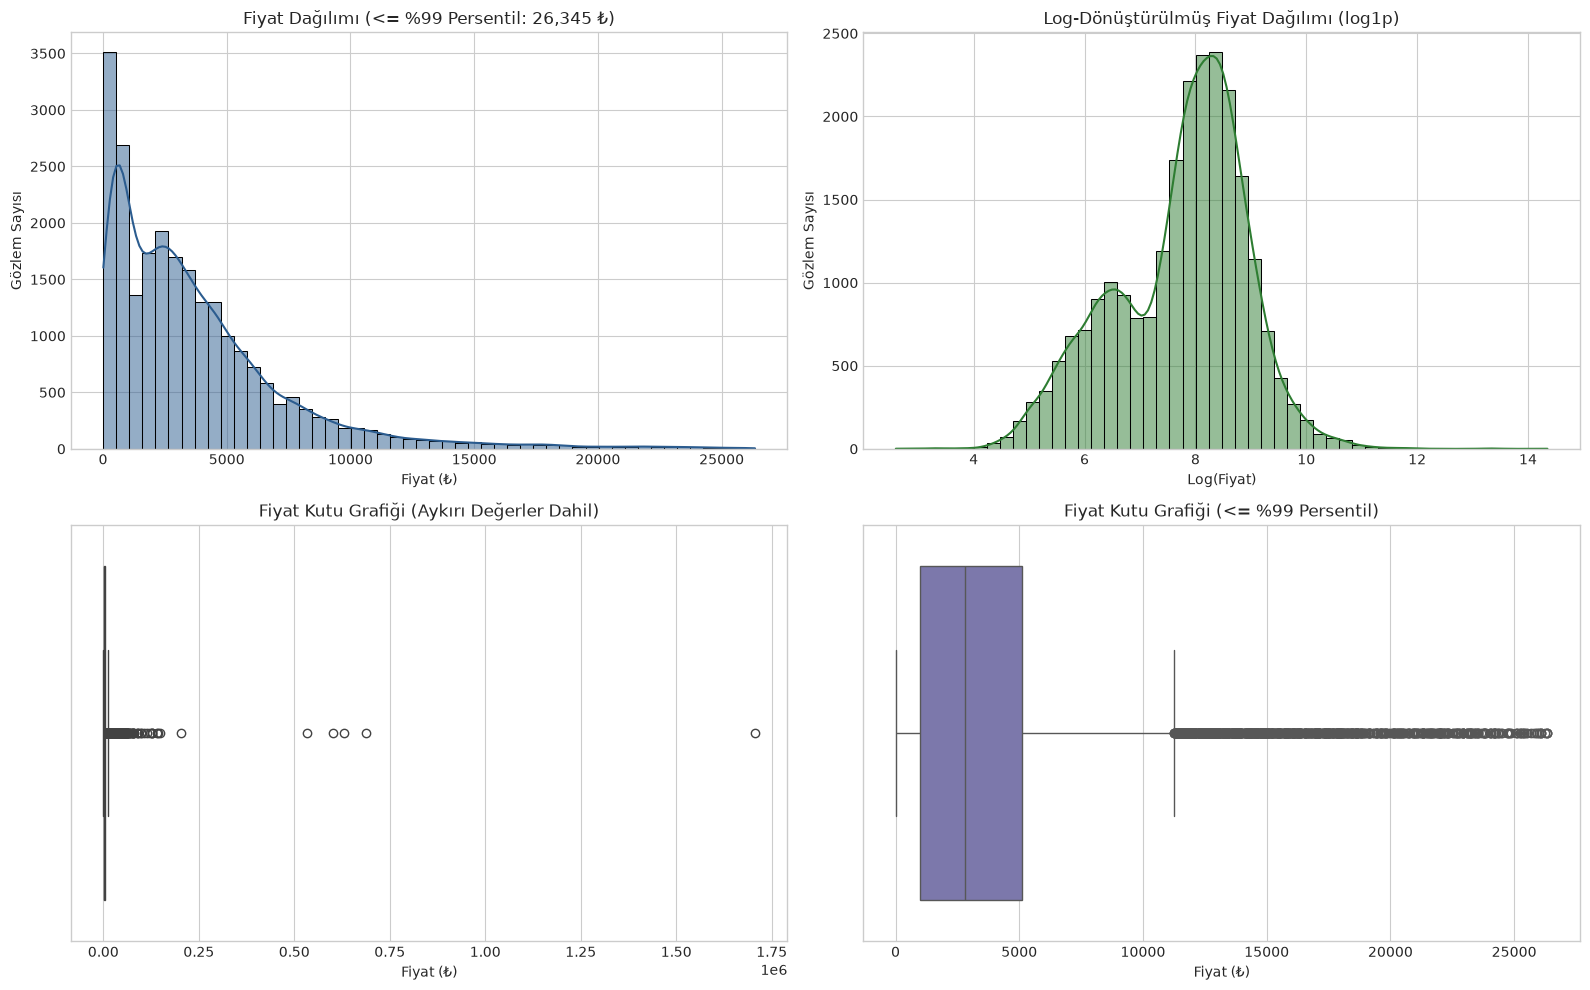

In [10]:
valid_prices = df_eda_price.dropna()
p99 = valid_prices.quantile(0.99)
log_prices = np.log1p(valid_prices[valid_prices > 0])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Ham Fiyat Dağılımı (99. persentile kadar)
sns.histplot(valid_prices[valid_prices <= p99], bins=50, kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title(f'Fiyat Dağılımı (<= %99 Persentil: {p99:,.0f} ₺)', fontsize=12)
axes[0, 0].set_xlabel('Fiyat (₺)', fontsize=10)
axes[0, 0].set_ylabel('Gözlem Sayısı', fontsize=10)

# 2. Log-Dönüştürülmüş Fiyat Dağılımı
sns.histplot(log_prices, bins=50, kde=True, ax=axes[0, 1], color='#2e7d32')
axes[0, 1].set_title('Log-Dönüştürülmüş Fiyat Dağılımı (log1p)', fontsize=12)
axes[0, 1].set_xlabel('Log(Fiyat)', fontsize=10)
axes[0, 1].set_ylabel('Gözlem Sayısı', fontsize=10)

# 3. Kutu Grafiği (Genel Dağılım)
sns.boxplot(x=valid_prices, ax=axes[1, 0], color='#d95f02')
axes[1, 0].set_title('Fiyat Kutu Grafiği (Aykırı Değerler Dahil)', fontsize=12)
axes[1, 0].set_xlabel('Fiyat (₺)', fontsize=10)

# 4. Kutu Grafiği (<= %99 Persentil)
sns.boxplot(x=valid_prices[valid_prices <= p99], ax=axes[1, 1], color='#7570b3')
axes[1, 1].set_title(f'Fiyat Kutu Grafiği (<= %99 Persentil)', fontsize=12)
axes[1, 1].set_xlabel('Fiyat (₺)', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Kategorik Değişkenlerin ve Mekânsal Dağılımın İncelenmesi

Oda Tipi Dağılımı:
                 Gozlem_Sayisi  Oran_Pct
room_type                               
Entire home/apt          17939     67.36
Private room              8246     30.96
Hotel room                 309      1.16
Shared room                137      0.51


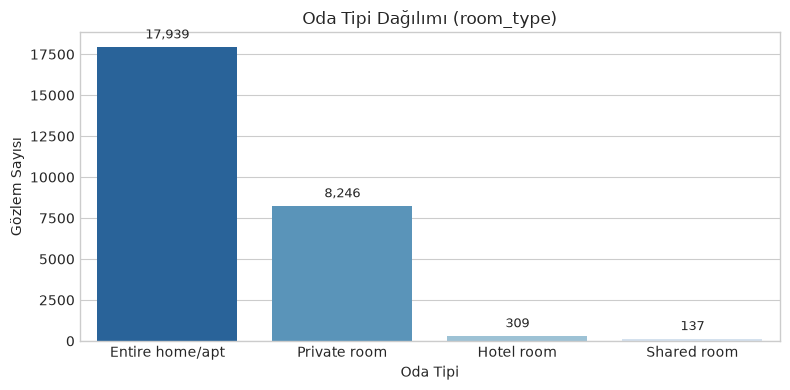

In [11]:
room_distribution = pd.DataFrame({
    'Gozlem_Sayisi': df_raw['room_type'].value_counts(dropna=False),
    'Oran_Pct': df_raw['room_type'].value_counts(normalize=True, dropna=False) * 100
})

print("Oda Tipi Dağılımı:")
print(room_distribution)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=room_distribution.index, y='Gozlem_Sayisi', data=room_distribution, palette='Blues_r')
plt.title('Oda Tipi Dağılımı (room_type)', fontsize=12)
plt.xlabel('Oda Tipi', fontsize=10)
plt.ylabel('Gözlem Sayısı', fontsize=10)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

Toplam İlçe Sayısı: 39


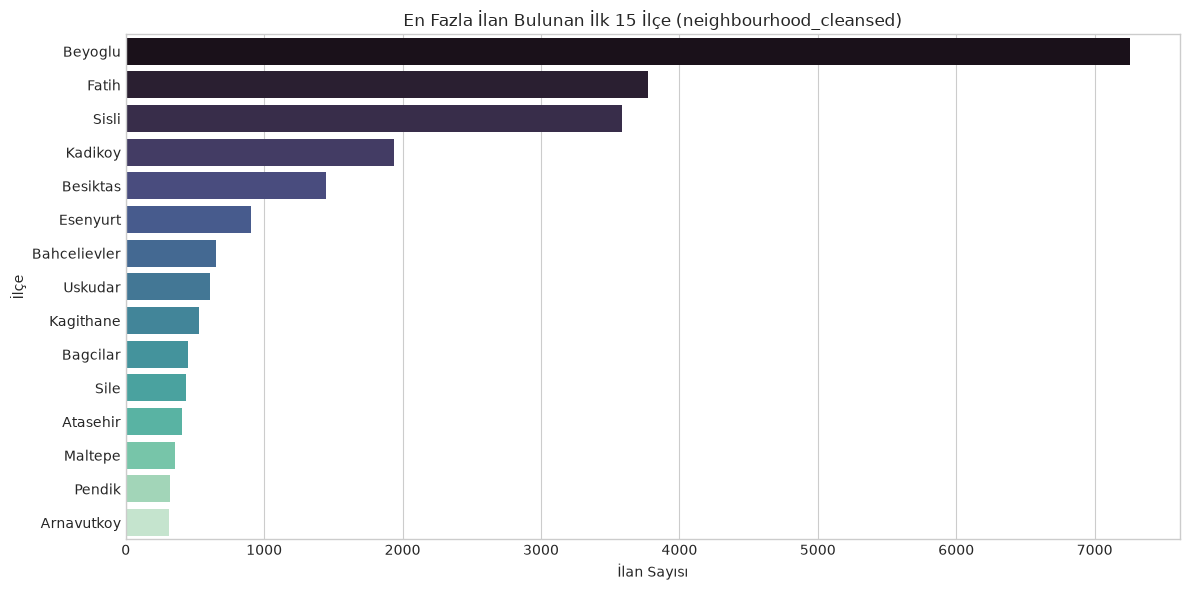

In [12]:
neighborhood_distribution = df_raw['neighbourhood_cleansed'].value_counts()
print(f"Toplam İlçe Sayısı: {df_raw['neighbourhood_cleansed'].nunique()}")

plt.figure(figsize=(12, 6))
top15_neighborhoods = neighborhood_distribution.head(15)
sns.barplot(x=top15_neighborhoods.values, y=top15_neighborhoods.index, palette='mako')
plt.title('En Fazla İlan Bulunan İlk 15 İlçe (neighbourhood_cleansed)', fontsize=12)
plt.xlabel('İlan Sayısı', fontsize=10)
plt.ylabel('İlçe', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Keşifsel Veri Analizi (EDA) Çıkarımları

* **Veri Seti Hacmi:** Veri seti 26.631 gözlem ve 90 sütundan oluşmaktadır (61 sayısal, 29 kategorik/metin).
* **Eksik Veri Profili:** Toplam 50 değişkende eksiklik mevcuttur. 14 kolonda eksiklik oranı %50'nin üzerindedir (13 kolon tamamen boştur).
* **Hedef Değişken Davranışı:** Fiyat dağılımı aşırı sağa çarpıktır (medyan: 2.853 ₺, ortalama: 4.347 ₺, maksimum: 1.706.000 ₺). 2.688 gözlemde fiyat değeri boştur.
* **Mekânsal Yoğunluk:** İlanların %67.36'sı tüm ev/daire, %30.96'sı özel oda tipindedir. Toplam ilanların %55'i Beyoğlu, Fatih ve Şişli ilçelerinde kümelenmiştir.


---
# Bölüm II: Veri Temizleme ve Ön İşleme Hattı

EDA bulguları doğrultusunda, modelleme aşamasına girmeden önce veri setinin tutarlılığını sağlamak amacıyla çok adımlı veri temizleme hattı uygulanmaktadır.


### 2.1. Yüksek Seyreklik Gösteren Sütunların Ayıklanması

In [13]:
columns_to_drop = high_sparsity_columns['Degisken_Adi'].tolist()
df_cleaned = df_raw.drop(columns=columns_to_drop).copy()

print(f"Kaldırılan Sütun Sayısı: {len(columns_to_drop)}")
print(f"Kalan Sütun Sayısı: {df_cleaned.shape[1]}")

Kaldırılan Sütun Sayısı: 14
Kalan Sütun Sayısı: 76


### 2.2. Hedef Değişken (`price`) Formatlama ve Gözlem Filtreleme

In [14]:
df_cleaned['price'] = df_cleaned['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_cleaned['price'] = pd.to_numeric(df_cleaned['price'], errors='coerce')

initial_count = len(df_cleaned)
df_cleaned = df_cleaned[df_cleaned['price'].notnull() & (df_cleaned['price'] > 0)].copy()
filtered_count = initial_count - len(df_cleaned)

print(f"Fiyatı Eksik/Geçersiz Olduğu İçin Filtrelenen Satır Sayısı: {filtered_count:,}")
print(f"Kalan Geçerli Gözlem Sayısı: {len(df_cleaned):,}")

Fiyatı Eksik/Geçersiz Olduğu İçin Filtrelenen Satır Sayısı: 2,688
Kalan Geçerli Gözlem Sayısı: 23,943


### 2.3. Eksik Değerlerin İmpütasyonu (Data Imputation)

In [15]:
# Kategorik / Metin değişkenler
cat_cols = df_cleaned.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# İnceleme sıklığı değişkeni
if 'reviews_per_month' in df_cleaned.columns:
    df_cleaned['reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(0.0)

# Sayısal değişkenler için medyan ataması
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

remaining_null_count = df_cleaned.isnull().sum().sum()
print(f"Veri Setinde Kalan Toplam Null Değer Sayısı: {remaining_null_count}")

Veri Setinde Kalan Toplam Null Değer Sayısı: 0


### 2.4. Temizlenmiş Veri Setinin Dışa Aktarımı

In [16]:
processed_dir = os.path.join('..', 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

processed_file_path = os.path.join(processed_dir, 'cleaned_listings.csv')
df_cleaned.to_csv(processed_file_path, index=False)

print(f"Dosya Başarıyla Kaydedildi: {processed_file_path}")
print(f"Kayıt Boyutu: {df_cleaned.shape[0]:,} satır, {df_cleaned.shape[1]} sütun")

Dosya Başarıyla Kaydedildi: ..\data\processed\cleaned_listings.csv
Kayıt Boyutu: 23,943 satır, 76 sütun


### 2.5. Temizleme Öncesi ve Sonrası Karşılaştırma Analizi

In [17]:
comparison_table = pd.DataFrame({
    'Metrik': [
        'Satır Sayısı (Gözlem)',
        'Sütun Sayısı (Değişken)',
        'Fiyat Veri Tipi',
        'Fiyatı Eksik Gözlem',
        'Toplam Eksik Hücre',
        'Min Fiyat (₺)',
        'Medyan Fiyat (₺)',
        'Ortalama Fiyat (₺)',
        'Max Fiyat (₺)'
    ],
    'Ham Veri (listings.csv)': [
        f"{df_raw.shape[0]:,}",
        f"{df_raw.shape[1]}",
        str(df_raw['price'].dtype),
        f"{df_raw['price'].isnull().sum():,}",
        f"{df_raw.isnull().sum().sum():,}",
        f"{valid_prices.min():,.2f}",
        f"{valid_prices.median():,.2f}",
        f"{valid_prices.mean():,.2f}",
        f"{valid_prices.max():,.2f}"
    ],
    'İşlenmiş Veri (cleaned_listings.csv)': [
        f"{df_cleaned.shape[0]:,}",
        f"{df_cleaned.shape[1]}",
        str(df_cleaned['price'].dtype),
        "0",
        "0",
        f"{df_cleaned['price'].min():,.2f}",
        f"{df_cleaned['price'].median():,.2f}",
        f"{df_cleaned['price'].mean():,.2f}",
        f"{df_cleaned['price'].max():,.2f}"
    ]
})

comparison_table

,Metrik,Ham Veri (listings.csv),İşlenmiş Veri (cleaned_listings.csv)
0,Satır Sayısı (Gözlem),"26,631","23,943"
1,Sütun Sayısı (Değişken),90,76
2,Fiyat Veri Tipi,str,float64
3,Fiyatı Eksik Gözlem,"2,688",0
4,Toplam Eksik Hücre,"523,651",0
5,Min Fiyat (₺),12.40,12.40
6,Medyan Fiyat (₺),"2,853.00","2,853.00"
7,Ortalama Fiyat (₺),"4,347.11","4,347.11"
8,Max Fiyat (₺),"1,706,000.45","1,706,000.45"


## 9. Yönetici Özeti ve Analitik Bulgular

1. **Boyut ve Şema Optimizasyonu:** %50'den fazla seyreklik gösteren 14 değişken veri setinden çıkarılarak sütun sayısı 90'dan 76'ya optimize edilmiştir.
2. **Hedef Değişken Tutarlılığı:** `price` değişkeni sayısal formata dönüştürülmüş, etiketi eksik olan 2.688 satır ayıklanarak 23.943 geçerli gözlem elde edilmiştir.
3. **Eksiksiz Veri Bütünlüğü:** Kalan tüm eksik değerler uygun istatistiksel yöntemlerle doldurularak veri setindeki eksik veri oranı %0'a indirilmiştir.
4. **Dışa Aktarım:** Hazırlanan veri seti, Aykırı Değer (Outlier) analizi ve özellik mühendisliği adımlarında kullanılmak üzere `data_science/data/processed/cleaned_listings.csv` konumunda serileştirilmiştir.
